In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('../data/raw/nba_pergame_2526.csv')
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
0,1.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,35.8,10.8,22.8,...,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,MVP-4CPOY-8ASNBA1,doncilu01
1,2.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,33.2,10.8,19.4,...,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,MVP-1CPOY-1ASNBA1,gilgesh01
2,3.0,Anthony Edwards,24.0,MIN,SG,61.0,60.0,35.0,9.9,20.2,...,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,CPOY-3AS,edwaran01
3,4.0,Jaylen Brown,29.0,BOS,SF,71.0,71.0,34.4,10.4,21.7,...,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,MVP-6ASNBA2,brownja02
4,5.0,Tyrese Maxey,25.0,PHI,PG,70.0,70.0,38.0,9.9,21.4,...,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,CPOY-7ASNBA3,maxeyty01


In [4]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(734, 32)
['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Awards', 'Player-additional']
Rk                     1
Player                 0
Age                    1
Team                   1
Pos                    1
G                      1
GS                     1
MP                     1
FG                     1
FGA                    1
FG%                    3
3P                     1
3PA                    1
3P%                   51
2P                     1
2PA                    1
2P%                    7
eFG%                   3
FT                     1
FTA                    1
FT%                   31
ORB                    1
DRB                    1
TRB                    1
AST                    1
STL                    1
BLK                    1
TOV                    1
PF                     1
PTS                    1
Awa

In [15]:
df_clean = df[~df.duplicated(subset='Player', keep=False) | df['Team'].isin(['2TM', '3TM', '4TM'])]

In [26]:
df_clean[df_clean['Player'] == 'Kevin Durant']

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
14,15.0,Kevin Durant,37.0,HOU,SF,78.0,78.0,36.4,9.2,17.6,...,4.9,5.5,4.8,0.8,0.9,3.2,1.8,26.0,CPOY-9ASNBA2,duranke01


In [23]:
df_clean[df_clean['Player'].isin(['Victor Wembanyama', 'Nikola Jokić', 'Giannis Antetokounmpo', 'Karl-Anthony Towns'])][['Player', 'FGA', 'FG%', 'PTS']]

,Player,FGA,FG%,PTS
7,Nikola Jokić,17.4,0.569,27.7
8,Giannis Antetokounmpo,16.6,0.624,27.6
16,Victor Wembanyama,16.9,0.512,25.0
47,Karl-Anthony Towns,13.8,0.501,20.1


In [42]:
df_clean[df_clean['Pos'].isin(['PG', 'SG', 'SF']) & (df_clean['MP'] < 30) & (df_clean['PTS'] < 15) & (df_clean['GS'] >= 50)][['GS', 'Player', 'PTS', 'MP', 'FGA', 'FG%']]

,GS,Player,PTS,MP,FGA,FG%
145,61.0,Ace Bailey,13.8,27.6,12.4,0.443
148,56.0,Jalen Suggs,13.8,27.6,11.4,0.435
172,58.0,Collin Gillespie,12.7,28.5,10.5,0.418
177,69.0,Jaylen Wells,12.5,26.4,10.1,0.431
178,68.0,Max Christie,12.3,29.1,9.4,0.441
187,77.0,Duncan Robinson,12.2,27.4,9.1,0.456
202,56.0,Bilal Coulibaly,11.7,26.2,9.7,0.425
210,54.0,Pelle Larsson,11.4,26.4,8.0,0.496
214,68.0,Julian Champagnie,11.1,27.6,8.4,0.437
236,68.0,A.J. Green,10.4,29.1,7.9,0.424


In [53]:
df_stars = df_clean[df_clean['Pos'].isin(['PG', 'SG', 'SF']) & (df_clean['MP'] > 28) & (df_clean['PTS'] > 15) & (df_clean['GS'] >= 50)].copy()

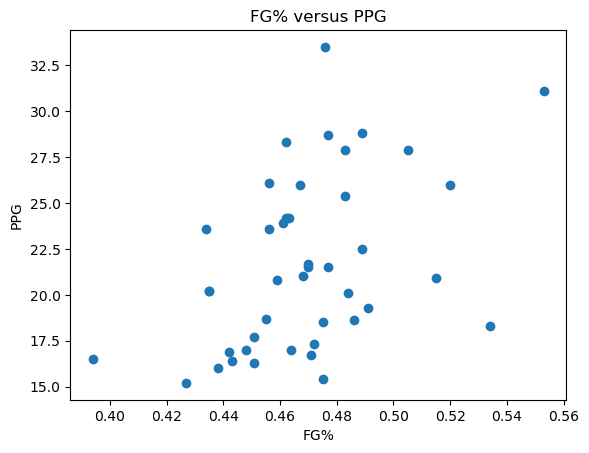

In [54]:
plt.scatter(df_stars['FG%'], df_stars['PTS'])
plt.xlabel('FG%')
plt.ylabel('PPG')
plt.title('FG% versus PPG')
plt.show()

In [55]:
# fit a regression line
m, b = np.polyfit(df_stars['FG%'], df_stars['PTS'], 1)

# calculate predicted PTS for each player
df_stars['predicted_PTS'] = m * df_stars['FG%'] + b

# calculate residuals
df_stars['residual'] = df_stars['PTS'] - df_stars['predicted_PTS']

In [56]:
df_stars[['Player', 'residual']].sort_values('residual')


,Player,residual
67,Amen Thompson,-8.000347
112,Andrew Wiggins,-6.690268
94,Stephon Castle,-5.104839
83,Ryan Rollins,-4.576196
88,Payton Pritchard,-4.305338
63,De'Aaron Fox,-4.275198
100,Jrue Holiday,-4.077694
35,LeBron James,-4.044559
55,RJ Barrett,-3.931984
65,Kon Knueppel,-3.590268


In [64]:
df_stars['TS%'] = df_stars['PTS'] / (2 * (df_stars['FGA'] + 0.44 * df_stars['FTA']))

In [73]:
print(df_stars[['Player', 'TS%']].sort_values('TS%', ascending=False))

                       Player       TS%
1     Shai Gilgeous-Alexander  0.665668
14               Kevin Durant  0.642292
65               Kon Knueppel  0.632176
5               Kawhi Leonard  0.627926
15               Jamal Murray  0.622915
2             Anthony Edwards  0.616227
6            Donovan Mitchell  0.614971
0                 Luka Dončić  0.614814
31            Trey Murphy III  0.613304
21               James Harden  0.611399
36   Nickeil Alexander-Walker  0.611189
24             Keyonte George  0.608875
29              Norman Powell  0.608866
46               Desmond Bane  0.607324
17                Deni Avdija  0.600556
67              Amen Thompson  0.595858
18         Michael Porter Jr.  0.595004
35               LeBron James  0.592672
4                Tyrese Maxey  0.588602
55                 RJ Barrett  0.586412
12               Devin Booker  0.586148
112            Andrew Wiggins  0.585284
88           Payton Pritchard  0.584273
83               Ryan Rollins  0.583513


In [70]:
print(df_stars)

       Rk                    Player   Age Team Pos     G    GS    MP    FG  \
0     1.0               Luka Dončić  26.0  LAL  PG  64.0  64.0  35.8  10.8   
1     2.0   Shai Gilgeous-Alexander  27.0  OKC  PG  68.0  68.0  33.2  10.8   
2     3.0           Anthony Edwards  24.0  MIN  SG  61.0  60.0  35.0   9.9   
3     4.0              Jaylen Brown  29.0  BOS  SF  71.0  71.0  34.4  10.4   
4     5.0              Tyrese Maxey  25.0  PHI  PG  70.0  70.0  38.0   9.9   
5     6.0             Kawhi Leonard  34.0  LAC  SF  65.0  65.0  32.1   9.8   
6     7.0          Donovan Mitchell  29.0  CLE  SG  70.0  70.0  33.5   9.7   
12   13.0              Devin Booker  29.0  PHO  SG  64.0  64.0  33.5   8.5   
13   14.0             Jalen Brunson  29.0  NYK  PG  74.0  74.0  35.0   9.3   
14   15.0              Kevin Durant  37.0  HOU  SF  78.0  78.0  36.4   9.2   
15   16.0              Jamal Murray  28.0  DEN  PG  75.0  75.0  35.4   8.8   
17   18.0               Deni Avdija  25.0  POR  SF  66.0  66.0  

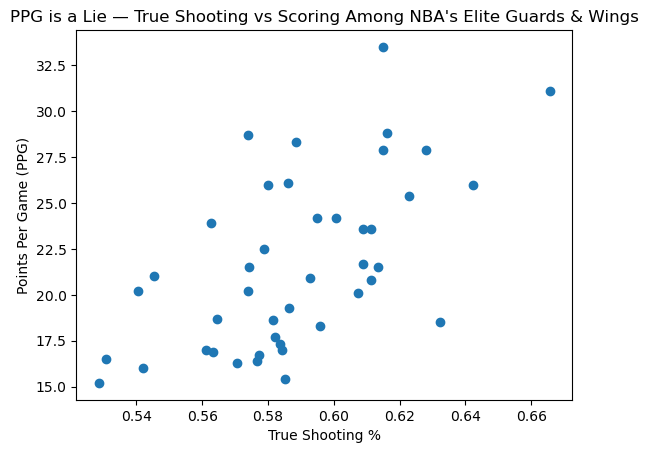

In [80]:
plt.scatter(df_stars['TS%'], df_stars['PTS'])
plt.xlabel('True Shooting %')
plt.ylabel('Points Per Game (PPG)')
plt.title("PPG is a Lie — True Shooting vs Scoring Among NBA's Elite Guards & Wings")
plt.axvline
plt.axhline
plt.show()

In [77]:
# fit a regression line
m, b = np.polyfit(df_stars['TS%'], df_stars['PTS'], 1)

# calculate predicted PTS for each player
df_stars['predicted_PTS'] = m * df_stars['TS%'] + b

# calculate residuals
df_stars['residual'] = df_stars['PTS'] - df_stars['predicted_PTS']

In [78]:
df_stars[['Player', 'residual']].sort_values('residual')

,Player,residual
65,Kon Knueppel,-7.301626
112,Andrew Wiggins,-5.958008
88,Payton Pritchard,-4.262152
98,Immanuel Quickley,-4.140042
67,Amen Thompson,-4.060036
94,Stephon Castle,-3.900951
83,Ryan Rollins,-3.890177
100,Jrue Holiday,-3.678635
74,Saddiq Bey,-3.354707
46,Desmond Bane,-3.346578


In [79]:
df_stars[['PTS', 'TS%']].mean()

PTS    21.660465
TS%     0.588476
dtype: float64